In [1]:
from torchvision import datasets, transforms
import torch

In [2]:
dataset = datasets.CIFAR10(
        root="./data",
        train=True,
        download=True,
        transform=transforms.Compose(
            [
                transforms.RandomHorizontalFlip(),
                transforms.ToTensor(),
                # transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
            ]
        ),
    )

Files already downloaded and verified


In [3]:

train_loader = torch.utils.data.DataLoader(
    dataset, batch_size=20, shuffle=True, drop_last=True
)

In [4]:
from torchvision.utils import make_grid
from torchvision.transforms import ToPILImage
import matplotlib.pyplot as plt

torch.Size([20, 3, 32, 32])
torch.Size([20])
tensor([5, 2, 7, 3, 7, 8, 5, 2, 9, 4, 6, 3, 7, 0, 5, 0, 7, 5, 5, 4])


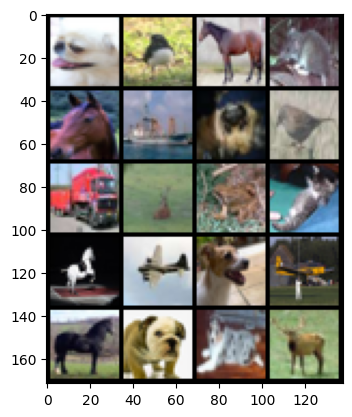

In [5]:

train_loader = torch.utils.data.DataLoader(
    dataset, batch_size=20, shuffle=True, drop_last=True
)

for batch in train_loader:
    print(batch[0].shape)
    print(batch[1].shape)
    print(batch[1])
    grid = make_grid(batch[0],nrow=4)
    img = ToPILImage()(grid)
    plt.imshow(img)
    break

In [6]:
dataset.class_to_idx

{'airplane': 0,
 'automobile': 1,
 'bird': 2,
 'cat': 3,
 'deer': 4,
 'dog': 5,
 'frog': 6,
 'horse': 7,
 'ship': 8,
 'truck': 9}

In [7]:
import os
from torchvision import io as tvio
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, utils

In [8]:
from typing import Callable, Dict, List, Tuple


class KhayyamWordDataset(Dataset):
    def __init__(self, root_dir: str, idx_range: Tuple[int,int], transform: Callable =None):
        self.root_dir = root_dir
        self.idx_min = idx_range[0]
        self.idx_max = idx_range[1]
        self.transform = transform

        self.data : List[Tuple[str,int]] = []
        self.count_per_class: Dict[int,int] = {}
        
        for word_idx in range(self.idx_min,self.idx_max):
            class_idx = word_idx - self.idx_min
            dir_path = f"{self.root_dir}/{word_idx}"
            filenames = os.listdir(dir_path)
            self.count_per_class[class_idx] = len(filenames)
            for file_name in filenames:
                    assert file_name[-4:] == ".jpg"
                    self.data.append((f"{dir_path}/{file_name}", class_idx))
        
    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        image_path,class_idx = self.data[idx]
        image = tvio.read_image(image_path)
        if self.transform is not None:
            image = self.transform(image)
        return (image, class_idx)

In [10]:
dataset = KhayyamWordDataset(
    root_dir="/mnt/speech6/bagher/nafshar/datasets/khayyam/3rd/images4",
    idx_range=(10,13),
    transform=transforms.Compose([
        transforms.ToPILImage(),
        # transforms.Grayscale(num_output_channels=1),
        transforms.Resize((75,126)),
        transforms.ToTensor(),
        # transforms.Normalize(mean=(0.5,),std=(0.5,))
    ]),
)

torch.Size([20, 3, 75, 126])
torch.Size([20])
tensor([2, 1, 0, 2, 2, 1, 1, 0, 2, 1, 2, 1, 1, 0, 2, 0, 1, 0, 1, 1])


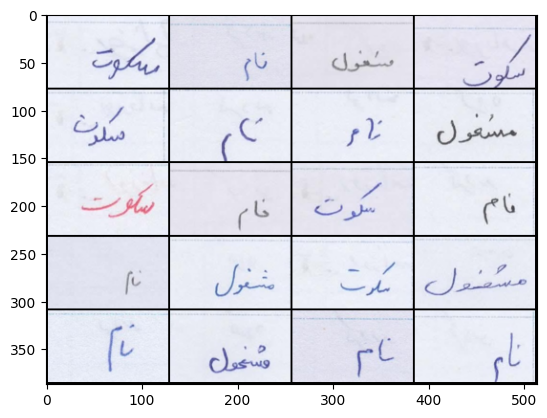

In [11]:

train_loader = torch.utils.data.DataLoader(
    dataset, batch_size=20, shuffle=True, drop_last=True
)

for batch in train_loader:
    print(batch[0].shape)
    print(batch[1].shape)
    print(batch[1])
    grid = make_grid(batch[0],nrow=4)
    img = ToPILImage()(grid)
    plt.imshow(img)
    break

In [14]:
dataset = KhayyamWordDataset(
    root_dir="/mnt/speech6/bagher/nafshar/datasets/khayyam/3rd/images4",
    idx_range=(1,11),
    transform=transforms.Compose([
        transforms.ToPILImage(),
        # transforms.Grayscale(num_output_channels=1),
        transforms.Resize((75,126),interpolation=transforms.InterpolationMode.BILINEAR),
        transforms.ToTensor(),
        # transforms.Normalize(mean=(0.5,),std=(0.5,))
    ]),
)

torch.Size([20, 3, 75, 126])
torch.Size([20])
tensor([3, 6, 4, 6, 1, 1, 2, 0, 6, 7, 4, 2, 7, 0, 9, 6, 1, 6, 1, 2])


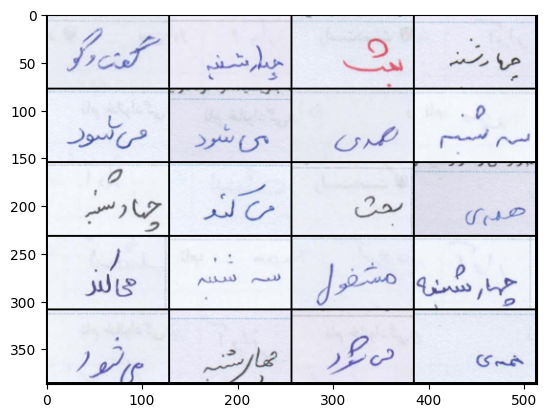

In [15]:

train_loader = torch.utils.data.DataLoader(
    dataset, batch_size=20, shuffle=True, drop_last=True
)

for batch in train_loader:
    print(batch[0].shape)
    print(batch[1].shape)
    print(batch[1])
    grid = make_grid(batch[0],nrow=4)
    img = ToPILImage()(grid)
    plt.imshow(img)
    break

In [24]:
dataset.count_per_class

{0: 81, 1: 81, 2: 81}